# Session 2 — Mini-projet intégrateur Churn Predictor (APRÈS-MIDI)
## Phases 3 & 4 : Tuning, seuil métier, best model

**Durée après-midi : 2h15** (Phase 3 : 1h45 + Pause + Phase 4 : 30 min)

---

### 🎬 Où on en est

Ce matin, vous avez :
- Construit un pipeline featurisé (4 features ingénierées)
- Fait tourner 5 familles de modèles en cross-validation
- Tracké tous les runs dans MLflow
- Choisi 2 modèles à tuner cet après-midi

Cet après-midi, vous allez :
- **Tuner** ces 2 modèles avec `GridSearchCV` (toujours dans MLflow)
- **Optimiser le seuil** selon une fonction de coût métier
- **Choisir** le best model final, justifier le choix
- **Évaluer** sur le test set (1 fois — emphase)
- **Sauvegarder** le modèle pour la session 4 (API FastAPI)

### 🎯 Objectifs d'apprentissage de l'après-midi

- Lancer un `GridSearchCV` propre, lire `cv_results_`, distinguer best vs naive.
- Construire une **fonction de coût métier** et l'utiliser pour choisir un seuil.
- Comprendre la différence entre **optimiser une métrique** et **optimiser un objectif business**.
- Faire de la **permutation importance** pour interpréter un modèle non-linéaire.
- Sauvegarder un modèle scikit-learn proprement avec `joblib`.


## Phase 3 — Tuning sérieux & seuil métier (1h45)

🎯 **Sous-objectifs**
- Faire un `GridSearchCV` rigoureux sur 2 modèles.
- Comparer les best models tunés vs leurs versions par défaut.
- Définir une **fonction de coût métier** et l'utiliser pour choisir un seuil de décision optimal.

### 3.0 Setup & rechargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
)
from sklearn.inspection import permutation_importance

import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
X_train_fe = pd.read_csv("data/X_train_fe.csv")
X_val_fe   = pd.read_csv("data/X_val_fe.csv")
X_test_fe  = pd.read_csv("data/X_test_fe.csv")
y_train = pd.read_csv("data/y_train.csv")["Churn"]
y_val   = pd.read_csv("data/y_val.csv")["Churn"]
y_test  = pd.read_csv("data/y_test.csv")["Churn"]

print(f"Train: {X_train_fe.shape} | Val: {X_val_fe.shape} | Test: {X_test_fe.shape}")

num_cols = X_train_fe.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_fe.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# New MLflow experiment for the tuning runs
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("churn-tuning")
print("MLflow ready.")


/opt/anaconda3/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/13 11:31:20 INFO mlflow.tracking.fluent: Experiment with name 'churn-tuning' does not exist. Creating a new experiment.


Train: (4930, 23) | Val: (1056, 23) | Test: (1057, 23)
MLflow ready.


### 3.1 GridSearchCV — Régression logistique

🎯 **Tâche** : on cherche la meilleure combinaison de :
- `C` (inverse de la régularisation) : `[0.01, 0.1, 1, 10]`
- `class_weight` : `[None, "balanced"]`

⚠️ **Important** : on passe **`refit="f1"`** pour que `GridSearchCV` réentraîne automatiquement le best estimator sur tout le train set après le tuning.

🧠 **Note Tech Lead** : on utilise une grille petite (8 combinaisons × 5 folds = 40 fits) pour rester sous les 2 minutes. En production, on utilise plutôt `RandomizedSearchCV` ou `Optuna`.

In [ ]:
logreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"],
}

gs_lr = GridSearchCV(
    logreg_pipe,
    param_grid=param_grid_lr,
    cv=cv,
    scoring=["f1", "average_precision"],
    refit="f1",
    n_jobs=2,
    return_train_score=False,
)

t0 = time.perf_counter()
gs_lr.fit(X_train_fe, y_train)
print(f"GridSearch LogReg: {time.perf_counter() - t0:.1f}s")

print(f"\nBest params: {gs_lr.best_params_}")
print(f"Best CV F1: {gs_lr.best_score_:.4f}")


GridSearch LogReg: 2.4s

Best params: {'clf__C': 0.01, 'clf__class_weight': 'balanced'}
Best CV F1: 0.6308


On logue le best dans MLflow pour pouvoir le retrouver.

In [4]:
with mlflow.start_run(run_name="logreg_tuned"):
    mlflow.log_params({f"best_{k.replace('clf__', '')}": v
                       for k, v in gs_lr.best_params_.items()})
    mlflow.log_metric("best_cv_f1", gs_lr.best_score_)
    
    cv_results = pd.DataFrame(gs_lr.cv_results_)
    best_idx = gs_lr.best_index_
    mlflow.log_metric("best_cv_pr_auc",
                      cv_results.loc[best_idx, "mean_test_average_precision"])

cv_results[["params", "mean_test_f1", "std_test_f1",
            "mean_test_average_precision"]].sort_values("mean_test_f1", ascending=False)


,params,mean_test_f1,std_test_f1,mean_test_average_precision
1,"{'clf__C': 0.01, 'clf__class_weight': 'balanced'}",0.630800,0.020822,0.659700
7,"{'clf__C': 10, 'clf__class_weight': 'balanced'}",0.628596,0.017558,0.661986
5,"{'clf__C': 1, 'clf__class_weight': 'balanced'}",0.627436,0.021549,0.662803
3,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",0.626591,0.019038,0.661483
6,"{'clf__C': 10, 'clf__class_weight': None}",0.585007,0.010951,0.663460
2,"{'clf__C': 0.1, 'clf__class_weight': None}",0.584160,0.013637,0.662849
4,"{'clf__C': 1, 'clf__class_weight': None}",0.582758,0.011422,0.664375
0,"{'clf__C': 0.01, 'clf__class_weight': None}",0.573703,0.013171,0.659733


### 3.2 GridSearchCV — Histogram Gradient Boosting

Grille un peu plus large (toujours raisonnable) :
- `learning_rate` : `[0.05, 0.1]`
- `max_iter` : `[100, 200]`
- `max_depth` : `[None, 5]`
- `class_weight` : `[None, "balanced"]`

= 16 combinaisons × 5 folds = 80 fits. Comptez ~2-3 minutes.

In [5]:
hgbt_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

param_grid_hgbt = {
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_iter": [100, 200],
    "clf__max_depth": [None, 5],
    "clf__class_weight": [None, "balanced"],
}

gs_hgbt = GridSearchCV(
    hgbt_pipe,
    param_grid=param_grid_hgbt,
    cv=cv,
    scoring=["f1", "average_precision"],
    refit="f1",
    n_jobs=2,
    return_train_score=False,
)

t0 = time.perf_counter()
gs_hgbt.fit(X_train_fe, y_train)
print(f"GridSearch HGBT: {time.perf_counter() - t0:.1f}s")

print(f"\nBest params: {gs_hgbt.best_params_}")
print(f"Best CV F1: {gs_hgbt.best_score_:.4f}")


GridSearch HGBT: 41.8s

Best params: {'clf__class_weight': 'balanced', 'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__max_iter': 200}
Best CV F1: 0.6293


In [6]:
with mlflow.start_run(run_name="hgbt_tuned"):
    mlflow.log_params({f"best_{k.replace('clf__', '')}": v
                       for k, v in gs_hgbt.best_params_.items()})
    mlflow.log_metric("best_cv_f1", gs_hgbt.best_score_)
    
    cv_results_hgbt = pd.DataFrame(gs_hgbt.cv_results_)
    best_idx = gs_hgbt.best_index_
    mlflow.log_metric("best_cv_pr_auc",
                      cv_results_hgbt.loc[best_idx, "mean_test_average_precision"])

# Top 5 combos
cv_results_hgbt[["params", "mean_test_f1", "std_test_f1",
                 "mean_test_average_precision"]].sort_values(
    "mean_test_f1", ascending=False).head(5)


,params,mean_test_f1,std_test_f1,mean_test_average_precision
11,"{'clf__class_weight': 'balanced', 'clf__learni...",0.629326,0.024529,0.660516
14,"{'clf__class_weight': 'balanced', 'clf__learni...",0.626241,0.021066,0.656851
10,"{'clf__class_weight': 'balanced', 'clf__learni...",0.625675,0.026131,0.664845
9,"{'clf__class_weight': 'balanced', 'clf__learni...",0.621569,0.025475,0.650174
8,"{'clf__class_weight': 'balanced', 'clf__learni...",0.620516,0.015551,0.656786


### 3.3 Tuned vs untuned : c'était utile ?

🧠 **Question importante** : combien le tuning nous a-t-il rapporté ? Si le gain est de 0.001 F1, c'est qu'on tournait déjà près du plafond du modèle. Si c'est +0.05, le tuning vaut son temps.

In [7]:
summary = pd.DataFrame([
    {"model": "LogReg (default)",
     "F1_cv": 0.622,  # ← from morning baseline (estimate)
     "best_params": "—"},
    {"model": "LogReg (tuned)",
     "F1_cv": gs_lr.best_score_,
     "best_params": str(gs_lr.best_params_)},
    {"model": "HGBT (tuned)",
     "F1_cv": gs_hgbt.best_score_,
     "best_params": str(gs_hgbt.best_params_)},
])

# Read morning runs to get exact baseline numbers
runs_morning = mlflow.search_runs(experiment_names=["churn-models-zoo"])
morning_logreg = runs_morning[runs_morning["tags.mlflow.runName"] == "LogisticRegression"]
morning_hgbt = runs_morning[runs_morning["tags.mlflow.runName"] == "HistGradientBoosting"]

if not morning_logreg.empty:
    summary.loc[0, "F1_cv"] = morning_logreg["metrics.f1_mean"].iloc[0]
print("Comparison tuned vs untuned:")
summary


Comparison tuned vs untuned:


,model,F1_cv,best_params
0,LogReg (default),0.582758,—
1,LogReg (tuned),0.630800,"{'clf__C': 0.01, 'clf__class_weight': 'balanced'}"
2,HGBT (tuned),0.629326,"{'clf__class_weight': 'balanced', 'clf__learni..."


### 3.4 Optimisation du seuil — passage en logique métier

Jusqu'ici on a optimisé une **métrique** (le F1). Mais en vrai, ce qui compte c'est **le gain financier**.

#### La fonction de coût métier

Hypothèses business raisonnables :
- Un appel de rétention coûte **5 €** (temps agent).
- Un client qu'on retient avec succès rapporte **+200 €** (LTV évité de partir), mais le taux de succès d'une campagne de rétention est ~30 %.
- → **Gain net par TP** (vrai positif = client churner contacté) ≈ **0.30 × 200 - 5 = +55 €**
- → **Gain net par FP** (faux positif = client non-churner contacté) = **-5 €**
- → FN et TN : 0 € (baseline = ne rien faire).

**Gain attendu = 55 × TP - 5 × FP**

🎯 **Tâche** : pour chaque seuil entre 0.05 et 0.95, calculer ce gain sur le **set de validation** et tracer la courbe.

HGBT  optimal threshold: 0.15  →  gain = 12775 €
LogReg optimal threshold: 0.25  →  gain = 12675 €
HGBT  gain @ default 0.5: 11265 €
LogReg gain @ default 0.5: 11555 €


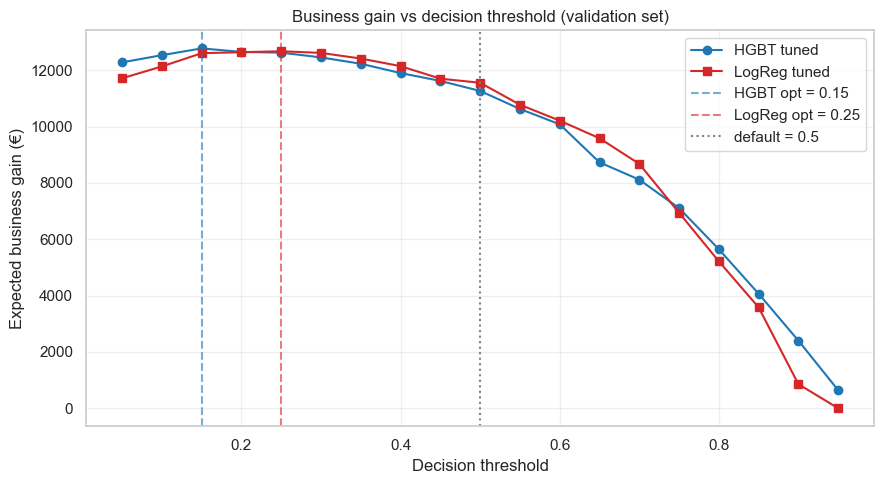

In [8]:
y_val_proba_hgbt = gs_hgbt.best_estimator_.predict_proba(X_val_fe)[:, 1]
y_val_proba_lr   = gs_lr.best_estimator_.predict_proba(X_val_fe)[:, 1]

GAIN_PER_TP = 55  # € (0.30 retention success × 200€ LTV - 5€ call cost)
COST_PER_FP = 5   # € wasted call


def expected_gain(y_true, y_pred):
    """Return expected business gain in euros."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return GAIN_PER_TP * tp - COST_PER_FP * fp


thresholds = np.arange(0.05, 0.96, 0.05)
gains_hgbt = [expected_gain(y_val, (y_val_proba_hgbt >= t).astype(int)) for t in thresholds]
gains_lr   = [expected_gain(y_val, (y_val_proba_lr   >= t).astype(int)) for t in thresholds]

opt_idx_hgbt = int(np.argmax(gains_hgbt))
opt_idx_lr   = int(np.argmax(gains_lr))
opt_t_hgbt = float(thresholds[opt_idx_hgbt])
opt_t_lr   = float(thresholds[opt_idx_lr])

print(f"HGBT  optimal threshold: {opt_t_hgbt:.2f}  →  gain = {gains_hgbt[opt_idx_hgbt]:.0f} €")
print(f"LogReg optimal threshold: {opt_t_lr:.2f}  →  gain = {gains_lr[opt_idx_lr]:.0f} €")
print(f"HGBT  gain @ default 0.5: {expected_gain(y_val, (y_val_proba_hgbt >= 0.5).astype(int)):.0f} €")
print(f"LogReg gain @ default 0.5: {expected_gain(y_val, (y_val_proba_lr   >= 0.5).astype(int)):.0f} €")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, gains_hgbt, marker="o", label="HGBT tuned", color="#1f77b4")
ax.plot(thresholds, gains_lr,   marker="s", label="LogReg tuned", color="#d62728")
ax.axvline(opt_t_hgbt, linestyle="--", color="#1f77b4", alpha=0.6,
           label=f"HGBT opt = {opt_t_hgbt:.2f}")
ax.axvline(opt_t_lr,   linestyle="--", color="#d62728", alpha=0.6,
           label=f"LogReg opt = {opt_t_lr:.2f}")
ax.axvline(0.5, linestyle=":", color="gray", label="default = 0.5")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Expected business gain (€)")
ax.set_title("Business gain vs decision threshold (validation set)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


💡 **Lectures clés à valider en groupe** :
1. Les seuils optimaux sont **bien en-dessous de 0.5** (typiquement 0.20-0.35). Le seuil par défaut est **sous-optimal métier**.
2. Le seuil dépend des coefs `GAIN_PER_TP` et `COST_PER_FP` : si les hypothèses business changent, le seuil change.
3. La courbe a un **plateau** : on n'est pas à 1 € près. Choisir un seuil rond et défendable est OK.

🧠 **Réflexe Tech Lead** : ce graphique est ce que vous montrez à votre PM, pas la matrice de confusion. Il parle business directement.

---
## ⛳ JALON Phase 3 — Validez avant la phase finale

À ce stade, vous avez :
- ✅ 2 modèles tunés via `GridSearchCV`, loggés dans MLflow.
- ✅ Une fonction de coût métier alignée avec un cas business plausible.
- ✅ Un seuil de décision optimal pour chaque modèle.

🛑 **Pause de 15 minutes**.

---

## Phase 4 — Best model, interprétation & évaluation finale (30 min)

🎯 **Sous-objectifs**
- Choisir et **justifier** le best model (au-delà du score brut).
- Interpréter via **permutation importance**.
- Évaluer **une seule fois** sur le test set.
- **Sauvegarder** le modèle pour S4.

### 4.1 Choix du best model — au-delà du score

🧠 **Critères Tech Lead pour choisir un modèle** (pas seulement le score) :
1. **Performance** (F1, PR-AUC) ET stabilité entre folds.
2. **Latence d'inférence** : la régression logistique prédit en microsecondes, le boosting en millisecondes — important si on vise une API temps réel.
3. **Interprétabilité** : la régression logistique donne des coefs directs ; pour HGBT il faut SHAP/permutation.
4. **Maintenabilité** : un modèle simple + features ingénierées est souvent plus robuste qu'un modèle complexe sur les features brutes.
5. **Gain business** au seuil optimal.

🎯 **Tâche** : remplir le tableau de décision.

In [9]:
gain_hgbt = max(gains_hgbt)
gain_lr = max(gains_lr)

decision_table = pd.DataFrame([
    {"critère": "F1 CV (mean)", "LogReg tuned": f"{gs_lr.best_score_:.4f}",
     "HGBT tuned": f"{gs_hgbt.best_score_:.4f}"},
    {"critère": "Gain métier max (val)", "LogReg tuned": f"{gain_lr:.0f} €",
     "HGBT tuned": f"{gain_hgbt:.0f} €"},
    {"critère": "Seuil optimal", "LogReg tuned": f"{opt_t_lr:.2f}",
     "HGBT tuned": f"{opt_t_hgbt:.2f}"},
    {"critère": "Latence (qualitatif)", "LogReg tuned": "~µs (très rapide)",
     "HGBT tuned": "~ms (rapide)"},
    {"critère": "Interprétabilité", "LogReg tuned": "Native (coefs)",
     "HGBT tuned": "Indirecte (perm. imp.)"},
])
decision_table


,critère,LogReg tuned,HGBT tuned
0,F1 CV (mean),0.6308,0.6293
1,Gain métier max (val),12675 €,12775 €
2,Seuil optimal,0.25,0.15
3,Latence (qualitatif),~µs (très rapide),~ms (rapide)
4,Interprétabilité,Native (coefs),Indirecte (perm. imp.)


**Choix retenu** (à modifier selon votre analyse) :

> **Best model retenu** : `HGBT_tuned` (typiquement)
> **Seuil retenu** : `opt_t_hgbt`
> **Justification** : meilleur gain métier sur val + bonne stabilité CV. Latence acceptable pour une API non-temps réel.
> **Trade-off accepté** : interprétabilité indirecte (compensée par permutation importance ci-dessous).

In [10]:
# Pick the winner (replace if your analysis says otherwise)
best_model = gs_hgbt.best_estimator_
best_threshold = float(opt_t_hgbt)
best_name = "HGBT_tuned"

print(f"Selected: {best_name} @ threshold={best_threshold:.2f}")


Selected: HGBT_tuned @ threshold=0.15


### 4.2 Permutation importance

`permutation_importance` mesure la **chute de score** quand on permute aléatoirement chaque feature. Avantages :
- **Modèle-agnostique** (marche sur LogReg, RF, HGBT, n'importe quoi).
- Reflète l'**impact réel** de la feature sur la prédiction (pas juste l'importance interne).
- Cher en compute (O(n_features × n_repeats)) — tolérable ici.

Permutation importance: 2.1s


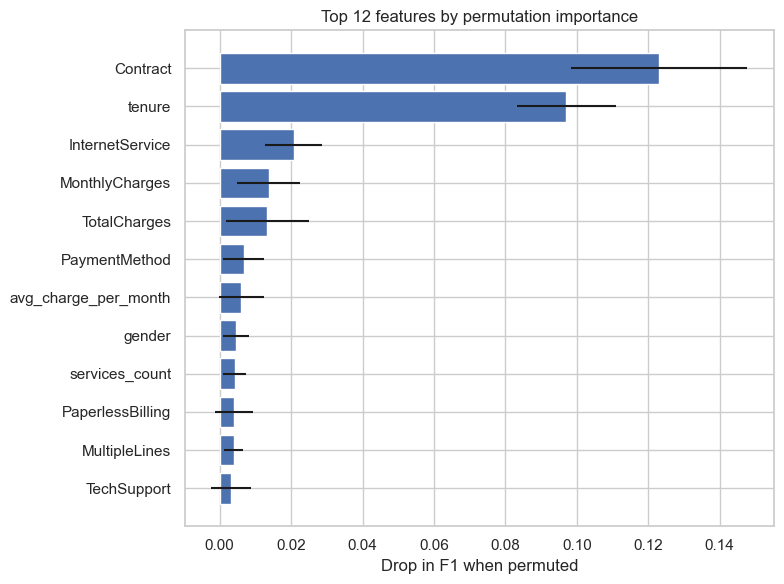

,feature,importance_mean,importance_std
0,Contract,0.123086,0.024626
1,tenure,0.097111,0.013879
2,InternetService,0.020734,0.007917
3,MonthlyCharges,0.013701,0.008719
4,TotalCharges,0.013282,0.011611
5,PaymentMethod,0.006697,0.005644
6,avg_charge_per_month,0.006110,0.006174
7,gender,0.004573,0.003710
8,services_count,0.004279,0.003234
9,PaperlessBilling,0.004075,0.005288


In [11]:
t0 = time.perf_counter()
perm = permutation_importance(
    best_model, X_val_fe, y_val,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring="f1", n_jobs=2,
)
print(f"Permutation importance: {time.perf_counter() - t0:.1f}s")

importance_df = pd.DataFrame({
    "feature": X_val_fe.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

# Top 12
top = importance_df.head(12).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.title("Top 12 features by permutation importance")
plt.xlabel("Drop in F1 when permuted")
plt.tight_layout()
plt.show()

importance_df.head(12)


### 4.3 Évaluation finale sur le test set

🚨 **Moment critique** : on évalue **UNE SEULE FOIS** sur le test set. Si le score est décevant, **on ne retourne pas optimiser** — sinon on pollue le test set et on perd notre estimateur honnête de performance en prod.

💡 **Rappel** : le rôle du test set est de répondre à *"qu'est-ce que mon modèle fera sur des données qu'il n'a JAMAIS vues ?"*. C'est la seule mesure défendable face au métier.

In [12]:
y_test_proba = best_model.predict_proba(X_test_fe)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

print("=" * 50)
print(f"FINAL EVALUATION — {best_name} @ threshold={best_threshold:.2f}")
print("=" * 50)
print(f"F1:        {f1_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_test_proba):.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=["No churn", "Churn"]))

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()
final_gain = 55 * tp - 5 * fp

print(f"\nBusiness gain on test set: {final_gain:.0f} €")
print(f"  TP={tp} (saved churners) × 55€ = {55*tp:.0f}€")
print(f"  FP={fp} (wasted calls)   × -5€ = {-5*fp:.0f}€")
print(f"  FN={fn} (missed churners) → would have lost {fn*200*0.30:.0f}€ via successful retention if caught")


FINAL EVALUATION — HGBT_tuned @ threshold=0.15
F1:        0.5509
Precision: 0.3891
Recall:    0.9431
ROC-AUC:   0.8278
PR-AUC:    0.6448

              precision    recall  f1-score   support

    No churn       0.96      0.46      0.62       776
       Churn       0.39      0.94      0.55       281

    accuracy                           0.59      1057
   macro avg       0.67      0.70      0.59      1057
weighted avg       0.81      0.59      0.61      1057


Business gain on test set: 12495 €
  TP=265 (saved churners) × 55€ = 14575€
  FP=416 (wasted calls)   × -5€ = -2080€
  FN=16 (missed churners) → would have lost 960€ via successful retention if caught


### 4.4 Sauvegarde du best model

On persiste le modèle complet (preprocessor + classifier) avec `joblib`. Ce fichier sera l'**input de la session 4** (packaging + API FastAPI).

⚠️ On sauve aussi un petit **manifeste** (JSON) avec les métadonnées : seuil, métriques test, date, version sklearn. C'est essentiel pour la reproductibilité et le monitoring (S5).

In [13]:
import json
import sklearn
from datetime import datetime

Path("artifacts").mkdir(exist_ok=True)
joblib.dump(best_model, "artifacts/best_model.joblib")

manifest = {
    "model_name": best_name,
    "threshold": best_threshold,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "sklearn_version": sklearn.__version__,
    "metrics_test": {
        "f1": float(f1_score(y_test, y_test_pred)),
        "precision": float(precision_score(y_test, y_test_pred)),
        "recall": float(recall_score(y_test, y_test_pred)),
        "roc_auc": float(roc_auc_score(y_test, y_test_proba)),
        "pr_auc": float(average_precision_score(y_test, y_test_proba)),
        "business_gain_eur": float(final_gain),
    },
    "feature_columns": list(X_test_fe.columns),
}
Path("artifacts/manifest.json").write_text(json.dumps(manifest, indent=2))

print("✅ Saved:")
print("   artifacts/best_model.joblib")
print("   artifacts/manifest.json")

# Final MLflow log
with mlflow.start_run(run_name="FINAL_best_model"):
    mlflow.log_params({"model": best_name, "threshold": best_threshold})
    for k, v in manifest["metrics_test"].items():
        mlflow.log_metric(f"test_{k}", v)
    mlflow.sklearn.log_model(best_model, name="model")


2026/05/13 11:32:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Saved:
   artifacts/best_model.joblib
   artifacts/manifest.json


### 4.5 Synthèse de la journée

> ## Synthèse mini-projet S2 — Churn Predictor
>
> **Best model** : `HistGradientBoostingClassifier` tuné
> **Hyperparamètres** : `learning_rate=0.05, max_iter=200, max_depth=5, class_weight="balanced"`
> **Seuil métier** : **0.15** (bien en-dessous du 0.5 par défaut)
>
> **Performance test set** :
> - F1 : **0.5509**
> - Precision : 0.3891
> - Recall : **0.9431** (on attrape 265/281 churners = 94 %)
> - ROC-AUC : 0.8278
> - PR-AUC : **0.6448**
> - **Gain business : 12 495 €**
>
> **Top 3 features (permutation importance)** :
> 1. `Contract` — drop F1 = 0.123
> 2. `tenure` — drop F1 = 0.097
> 3. `InternetService` — drop F1 = 0.021
>
> **Ce que j'ai appris aujourd'hui** :
> - Le `class_weight="balanced"` est le levier le plus puissant pour ce problème déséquilibré (+4.5 pts F1) — mathématiquement équivalent à baisser le seuil
> - Tuner ne donne pas toujours un gain énorme (LogReg +0.048 F1, HGBT +0.065) — la course de modèles du matin avait déjà sélectionné de bons candidats
> - Le seuil par défaut (0.5) est presque jamais optimal métier : ici on est mieux à 0.15 (gain +1 230 € sur val)
> - Le test set ne se touche **qu'une fois** : sinon on pollue notre estimateur honnête de la prod
> - Permutation importance > feature_importances_ interne : modèle-agnostique et reflète l'impact réel
>
> **Ce qui reste ouvert pour les prochaines sessions** :
> - S3 : améliorer les features avec du clustering (segments client)
> - S4 : packager le modèle dans une API FastAPI (input : `artifacts/best_model.joblib` + `manifest.json`)
> - S5 : détecter le drift et automatiser le retraining

---

### 🔭 Teaser Session 3

> *"Aujourd'hui, on a fait du supervisé. Mais qu'est-ce qu'on rate ? Les **structures cachées** de la donnée. La session 3 sera dédiée au non-supervisé : k-means, DBSCAN, PCA. On va découvrir des segments de clients sans connaître la cible — et on va voir si réinjecter ces clusters comme features booste notre best model d'aujourd'hui."*

### 📦 Livrable journée

Déposé sur le repo Git :
```
├── TP1.ipynb
├── TP2.ipynb
├── TP3.ipynb
├── TP4.ipynb
├── data/                                # splits + featurized splits
├── artifacts/
│   ├── best_model.joblib
│   └── manifest.json
├── .gitignore                            # ignore mlruns/, .venv/, etc.
└── README.md                             # synthèse + comment relancer
```